In [9]:
# Uncomment to install the required packages
# !pip install git+https://github.com/fagonzalezo/kdm.git@generative

In [10]:
import numpy as np
from scipy.stats import norm
from scipy.stats import gaussian_kde

import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import optimizers
from keras import losses
from keras import metrics
from keras.callbacks import ModelCheckpoint


from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

from kdm.models import KDMRegressModel
import kdm

from tqdm import tqdm

import matplotlib.pyplot as plt

In [11]:
# Function to visualize a 2D dataset
def plot_data(X, y):
    y_unique = np.unique(y)
    colors = plt.cm.rainbow(np.linspace(0.0, 1.0, y_unique.size))
    for this_y, color in zip(y_unique, colors):
        print(X.shape, y.shape, (y==this_y).shape)
        this_X = X[y == this_y, :]
        plt.scatter(this_X[:, 0], this_X[:, 1],  color=color,
                    alpha=0.5, edgecolor='k',
                    label="Class %s" % this_y)
    plt.legend(loc="best")
    plt.title("Data")

# Function to visualize the decission surface of a classifier
def plot_decision_region(X, pred_fun):
    min_x = np.min(X[:, 0])
    max_x = np.max(X[:, 0])
    min_y = np.min(X[:, 1])
    max_y = np.max(X[:, 1])
    min_x = min_x - (max_x - min_x) * 0.05
    max_x = max_x + (max_x - min_x) * 0.05
    min_y = min_y - (max_y - min_y) * 0.05
    max_y = max_y + (max_y - min_y) * 0.05
    x_vals = np.linspace(min_x, max_x, 50)
    y_vals = np.linspace(min_y, max_y, 50)
    XX, YY = np.meshgrid(x_vals, y_vals)
    grid_r, grid_c = XX.shape
    vals = [[XX[i, j], YY[i, j]] for i in range(grid_r) for j in range(grid_c)]
    preds = pred_fun(np.array(vals))
    ZZ = np.reshape(preds, (grid_r, grid_c))
    plt.contourf(XX, YY, ZZ, 100, cmap = plt.cm.coolwarm, vmin= 0, vmax=1)
    plt.colorbar()
    CS = plt.contour(XX, YY, ZZ, 100, levels = [0.1*i for i in range(1,10)])
    plt.clabel(CS, inline=1, fontsize=10)
    plt.xlabel("x")
    plt.ylabel("y")

def gen_pred_fun(clf):
    def pred_fun(X):
        return clf.predict(X)[:, 1]
    return pred_fun

def gen_pred_fun_reg(clf):
    def pred_fun(X):
        return clf.predict(X)
    return pred_fun



## 2 Generative regression with overlapping classes

In this example we want to see if the learned prototypes can capture the continous variation from one class to the other. The label of the synthetic dataset are binary, but we will use a regression model.

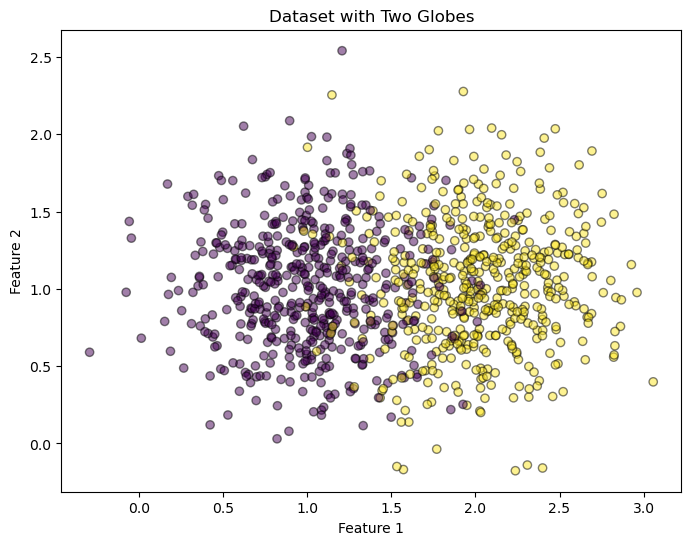

(1000, 1)


In [12]:
from sklearn.datasets import make_blobs

# Create a dataset with two blobs located at (1, 1) and (2, 1)
centers = [(1, 1), (2, 1)]
X_blobs, y_blobs = make_blobs(n_samples=1000, centers=centers, cluster_std=0.4, random_state=42)

# Plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='viridis', alpha=0.5, edgecolor='k')
plt.title("Dataset with Two Globes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

y_blobs = y_blobs.reshape(-1, 1) * 1.0
print(y_blobs.shape)
#y_blobs_ohe = keras.utils.to_categorical(y_blobs)
# scale y_blobs to be in the range [0.1, 0.9]
y_blobs = (y_blobs - np.min(y_blobs)) / (np.max(y_blobs) - np.min(y_blobs)) * 0.8 + 0.1
#y_blobs_ohe = (y_blobs_ohe - np.min(y_blobs_ohe)) / (np.max(y_blobs_ohe) - np.min(y_blobs_ohe)) * 0.8 + 0.1



Here we train a generative model as before, but we keep the sigma fixed, so that protoypes distribute evenly through the space where the training samples are.

In [14]:
encoded_size = 2
dim_y = 1
encoder = keras.Sequential([keras.layers.Identity()])
n_comp = 30

kdm_reg_model = KDMRegressModel(encoded_size=encoded_size,
                            dim_y=1,
                            encoder=encoder,
                            n_comp=n_comp,
                            sigma_x=0.05,
                            sigma_y=0.1,
                            min_sigma_y=0.05,
                            generative=1.0,
                            sigma_x_trainable=False)

# train the classifier
kdm_reg_model.compile(optimizer=optimizers.Adam(learning_rate=5e-3))
#kdm_model.predict(X_train[:10])
idx = np.random.randint(X_blobs.shape[0], size=n_comp)
kdm_reg_model.init_components(X_blobs[idx],
                          y_blobs[idx],
                          init_sigma=True)

kdm_reg_model.fit(X_blobs, y_blobs, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 3.7345
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3307
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.2865
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2502
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2075
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2016
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2540
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2069
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2054
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1820


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
(1000, 2) (1000,) (1000,)
(1000, 2) (1000,) (1000,)
Sigma_x: 0.2570904493331909
Sigma_y: -0.0007647688616998494


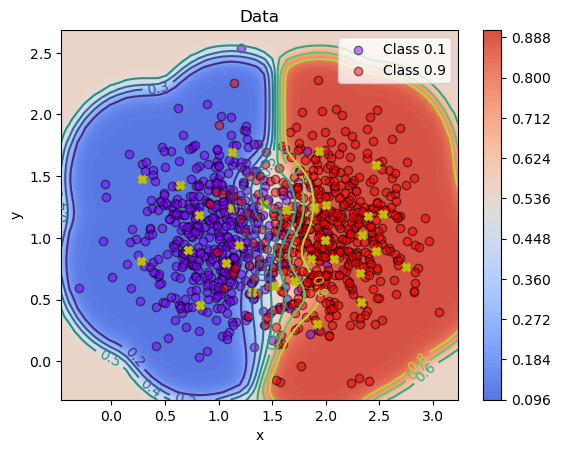

In [15]:
from kdm.utils import dm_rbf_expectation

def reg_pred_fun(kdm_reg_model):
    def pred_fun(X):
        rho_y = kdm_reg_model.predict(X)
        y_pred = keras.ops.convert_to_numpy(dm_rbf_expectation(rho_y))#.flatten()
        return y_pred
    return pred_fun

# Plot the decision region
plot_decision_region(X_blobs, reg_pred_fun(kdm_reg_model))
plot_data(X_blobs, y_blobs.flatten())
# plot the prototypes
plt.scatter(kdm_reg_model.kdm.c_x.numpy()[:, 0], kdm_reg_model.kdm.c_x.numpy()[:, 1], c='y', marker='X')
# Evaluate the classifier
#score = kdm_reg_model.evaluate(X_blobs, y_blobs, verbose=0)
#print('Test loss:', score[0])
#print('Test accuracy:', score[1])
print(f'Sigma_x: {kdm_reg_model.kernel.sigma.numpy()}')
print(f'Sigma_y: {kdm_reg_model.sigma_y.numpy()}')

As we can see that the prototypes are in fact evenly distributed. Since the classes are overlapping, we want to check how the $y$ component of the prototypes varies when we move from one class to the other. The following figure plots the $x$ component of the prototypes against the probability encoded by the $y$ component.

(30, 1) (30,) (30,)


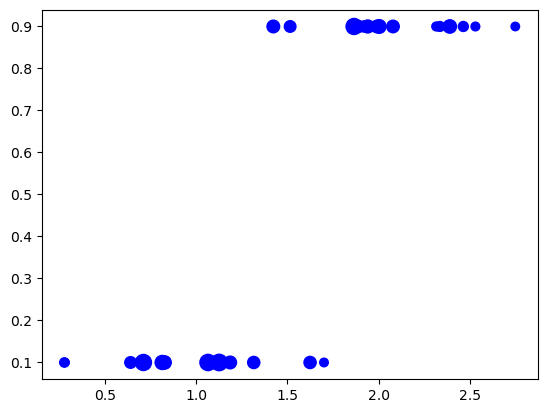

In [16]:
weights = np.abs(kdm_reg_model.kdm.c_w.numpy())
ys  = kdm_reg_model.kdm.c_y.numpy()
#ys = keras.utils.normalize(ys, order=2, axis=-1) ** 2
xs = kdm_reg_model.kdm.c_x.numpy()[:, 0]
# plot the prototypes with circles with size proportional to the weights
plt.scatter(xs, ys[:, 0], c='b', marker='o', s=weights*1000)
print(ys.shape, xs.shape, weights.shape)    

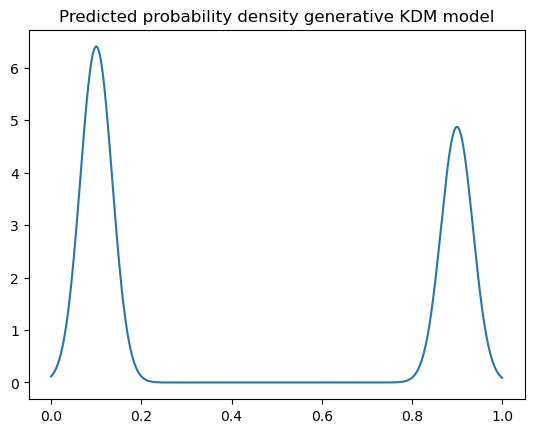

In [17]:
from kdm.utils import dm_rbf_loglik, dm2comp
x = np.atleast_2d(np.linspace(0, 1, 1000)).T
rho_y = keras.ops.cast(kdm_reg_model(np.array([[1.5, 1.]])), dtype='float32')
sigma_y = keras.ops.clip(kdm_reg_model.sigma_y, kdm_reg_model.min_sigma_y, np.inf)
loglik = dm_rbf_loglik(keras.ops.convert_to_tensor(x, dtype="float32"),rho_y,sigma_y)
lik = keras.ops.convert_to_numpy(keras.ops.exp(loglik))
plt.plot(x, lik)
plt.title("Predicted probability density generative KDM model")
plt.show()


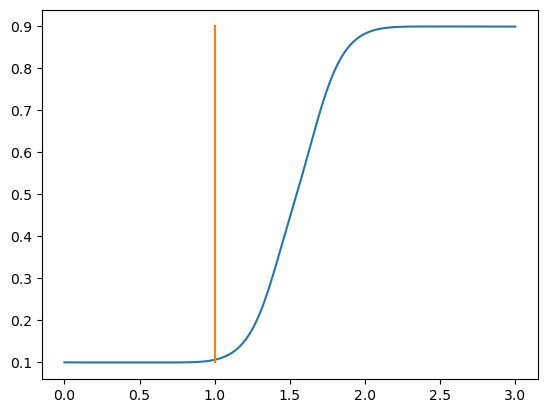

In [25]:
from kdm.utils import dm_rbf_loglik, dm2comp, dm_rbf_expectation
x = np.atleast_2d(np.linspace(0, 3, 1000)).T
x = np.concatenate([x, np.ones_like(x)], axis=1)
rho_y = keras.ops.cast(kdm_reg_model(x), dtype='float32')
pred = dm_rbf_expectation(keras.ops.convert_to_tensor(rho_y))
pred = keras.ops.convert_to_numpy(pred)
plt.plot(x, pred)
plt.show()

# 3 Generative image classification

We train a generative image classifier based on KDM. The dataset is a synthetic image classifier available at https://www.kaggle.com/datasets/gonzalorecioc/color-polygon-images. The images in the dataset correspond to polygons with different sizes, locations and colors. The dataset can be used for different classification and regression tasks. Here we will address a regression task, to estimate the radius of the enclosing circle of the polygon. However, we will address it as a classification task to see if the learned prototypes are able to capture the continuos nature of the underlining problem.

In [ ]:
# Download dataset
# https://www.kaggle.com/datasets/gonzalorecioc/color-polygon-images
# You have to upload your Kaggle api key: https://www.kaggle.com/docs/api#authentication

def get_polygon_dataset():
    ! pip install -q kaggle
    from google.colab import files
    files.upload()
    !mkdir ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    import kagglehub

    # Download latest version
    path = kagglehub.dataset_download("gonzalorecioc/color-polygon-images")
    return path

path = get_polygon_dataset()

#path = "./"
print("Path to dataset files:", path)

Saving kaggle.json to kaggle.json


100%|██████████| 8.00M/8.00M [00:00<00:00, 67.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gonzalorecioc/color-polygon-images/versions/1


In [ ]:
# to run this example download the data from
# and set the paths accordingly
# path = "/Users/fgonza/Documents/research/code/data/color_poly_images/"
targets_path = path + "/targets.csv"
images_path = path + "/images/content/images/"

In [ ]:
print(targets_path)
print(images_path)

/root/.cache/kagglehub/datasets/gonzalorecioc/color-polygon-images/versions/1/targets.csv
/root/.cache/kagglehub/datasets/gonzalorecioc/color-polygon-images/versions/1/images/content/images/


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the targets.csv file
targets_df = pd.read_csv(targets_path)

# split the data into train and test
train_df, test_df = train_test_split(targets_df, test_size=0.2, random_state=42)

# Print the maximum and minumum values of bound_circle_r column
print(f"Maximum bound_circle_r: {train_df['bound_circle_r'].max()}")
print(f"Minimum bound_circle_r: {train_df['bound_circle_r'].min()}")

Maximum bound_circle_r: 66
Minimum bound_circle_r: 10


In [ ]:
targets_df.head()

,Unnamed: 0,filename,sides,bg_color,fg_color,bound_circle_x,bound_circle_y,bound_circle_r,rotation
0,0,70aaa621-1345-4541-a954-ee9856daaf18.png,4,blue,pink,29,39,15,185
1,1,ea0d8d14-596a-4365-b007-6325fc96e0f4.png,3,black,yellow,66,66,21,215
2,2,48c1fc5a-8b6b-4555-bb6a-a7d42a5cedc2.png,4,yellow,red,59,103,20,59
3,3,ad721906-604c-4682-ae5d-15539ef1dbc7.png,3,green,pink,65,66,61,272
4,4,510dd5ea-fb92-432e-91cc-ed4654a03ebd.png,6,white,green,48,56,42,38


In [ ]:
import tensorflow as tf
import pandas as pd

def preprocess_image(image_path):
    """
    Loads an image from the given path and preprocesses it for the dataset.

    Args:
        image_path (str): The file path to the image.

    Returns:
        tf.Tensor: The preprocessed image tensor.
    """
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [224, 224])  # Resize to a fixed size (e.g., 224x224)
    image = tf.image.convert_image_dtype(image, tf.float32)  # Convert to float32 and normalize
    image = image / 255.0
    return image

def create_tf_dataset(dataframe, target_column='rotation',
                      batch_size=32, image_folder_path='',
                      shuffle=True, add_noise=False):
    """
    Converts a Pandas DataFrame into a TensorFlow dataset for image classification.

    Args:
        dataframe (pd.DataFrame): The input DataFrame containing image filenames and target labels.
        target_column (str, optional): The column name in the DataFrame representing the target labels.
                                       Defaults to 'rotation'.
        batch_size (int, optional): The batch size for the dataset. Defaults to 32.
        image_folder_path (str, optional): The path to the folder containing the images. Defaults to ''.
        shuffle (bool, optional): Whether to shuffle the dataset. Defaults to True.

    Returns:
        tf.data.Dataset: A TensorFlow dataset with preprocessed images and corresponding labels.
                           Images are loaded, resized, and normalized.
                           Target labels are scaled to a range between 0.1 and 0.9.
    """
    # Drop the 'Unnamed: 0' column if it exists
    if 'Unnamed: 0' in dataframe.columns:
        dataframe = dataframe.drop(columns=['Unnamed: 0'])

    # Append image folder path to filenames
    image_paths = [image_folder_path + '/' +  filename for filename in dataframe['filename'].values]
    target = dataframe[target_column].values / 70.# Normalize the target values
    # add noise
    if add_noise:
        target = target + np.random.normal(0, 0.15, target.shape)
        target = np.clip(target, 0, 1)

    # make target binary label
    target = (target > 0.5).astype(int)
    # make target a ohe
    target = keras.utils.to_categorical(target, num_classes=2)

    # Scale the target to [0.1, 0.9]
    target = (target - np.min(target)) / (np.max(target) - np.min(target)) * 0.8 + 0.1

    # Create a TensorFlow dataset from image paths and targets
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, target))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe))  # Shuffle if shuffle=True

    dataset = (dataset
                .map(lambda path, label: (preprocess_image(path), label),
                     num_parallel_calls=tf.data.AUTOTUNE)
                .batch(batch_size)
                .prefetch(buffer_size=tf.data.AUTOTUNE))

    return dataset

In [ ]:
import tensorflow as tf

train_ds = create_tf_dataset(train_df, target_column='bound_circle_r',
                             batch_size=128, image_folder_path=images_path,
                             shuffle=True, add_noise=True)

test_ds = create_tf_dataset(test_df, target_column='bound_circle_r',
                            batch_size=32, image_folder_path=images_path,
                            shuffle=False, add_noise=False)


In [ ]:
# prompt: For both train_ds and test_ds count the number of elements in each class

import numpy as np

# Assuming 'train_ds' and 'test_ds' are tf.data.Datasets
# Iterate through the datasets and count elements in each class
def count_class_elements(dataset):
    class_counts = {}
    for images, labels in dataset:
        for label in labels.numpy():
            class_idx = np.argmax(label) # Assuming one-hot encoding
            class_counts[class_idx] = class_counts.get(class_idx, 0) + 1
    return class_counts

train_class_counts = count_class_elements(train_ds)
test_class_counts = count_class_elements(test_ds)

print("Train Class Counts:", train_class_counts)
print("Test Class Counts:", test_class_counts)

Train Class Counts: {0: 3570, 1: 4430}
Test Class Counts: {1: 1076, 0: 924}


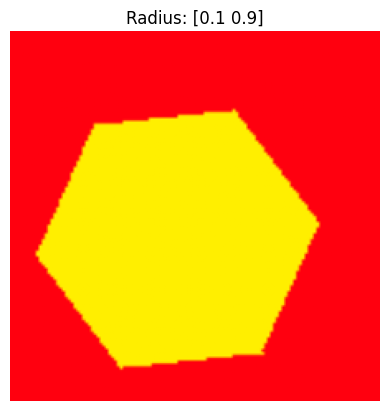

1.0 0.0
(224, 224, 3)


In [ ]:
# read an image from the dataset and plot it
for image, label in train_ds.take(1):
    plt.imshow(image[0])
    plt.title(f"Radius: {label[0].numpy()}")
    plt.axis('off')
    plt.show()
    print(np.max(image[0].numpy()), np.min(image[0].numpy()))
    print(image[0].shape)

In [ ]:
def create_encoder(input_shape, hidden_size, encoded_size):
    """
    Creates an encoder model using a pre-trained MobileNetV2 model.

    Args:
        input_shape (tuple): The shape of the input tensor.
        base_depth (int): The depth of the base model.
        encoded_size (int): The size of the encoded representation.

    Returns:
        keras.Model: The encoder model.
    """
    base_model = keras.applications.MobileNetV2(input_shape=input_shape,
                                                include_top=False,
                                                weights='imagenet')

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(hidden_size, activation=keras.activations.relu)(x)
    outputs = keras.layers.Dense(encoded_size)(x)

    encoder = keras.Model(inputs, outputs, name='encoder')
    return encoder


def run_experiment(encoded_size=10,
                   n_comp=64,
                   sigma_mult=1.0,
                   epochs=10,
                   batch_size=128):

    encoder = create_encoder(input_shape=(224, 224, 3), hidden_size=64, encoded_size=encoded_size)
    print(encoder.summary())
    # warm up the encoder with a small subset
    encoder_wmp = keras.Sequential([encoder,
                                    keras.layers.Dense(2, activation='softmax')])
    encoder_wmp.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                    loss=losses.categorical_crossentropy,
                    metrics=[metrics.categorical_accuracy])

    # train the encoder for 2 epoch
    subset_ds = train_ds
    encoder_wmp.fit(subset_ds, epochs=2, verbose=1)

    # Create a KDM classifier model

    kdm_disc = KDMClassModel(encoded_size=encoded_size,
                                dim_y=2,
                                encoder=encoder,
                                n_comp=n_comp,
                                sigma=1.0,
                                w_train=True)

    # initialize the prototypes using random sample from train_ds
    init_prot_x = []
    init_prot_y = []
    for image, label in train_ds.unbatch().take(n_comp):
        init_prot_x.append(image[None, ...])
        init_prot_y.append(label)
    init_prot_x = np.concatenate(init_prot_x, axis=0)
    print(init_prot_x.shape)
    init_prot_y = np.array(init_prot_y)
    kdm_disc.init_components(init_prot_x, init_prot_y,
                            init_sigma=True, sigma_mult=sigma_mult)
    print(f"Sigma: {kdm_disc.kdm.kernel.sigma.numpy()}")
    # Compile the model
    kdm_disc.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
                        loss=losses.categorical_crossentropy,
                        metrics=[metrics.categorical_accuracy])

    # Callback to save the best model
    checkpoint = keras.callbacks.ModelCheckpoint('best_model.weights.h5',
                                                 save_best_only=True,
                                                 save_weights_only=True)

    # train the classifier
    #kdm_disc.predict(X_train[:10])
    history = kdm_disc.fit(train_ds,
                  epochs=epochs,
                  batch_size=batch_size,
                  callbacks=[checkpoint],
                  validation_data=test_ds,
                  verbose=1)

    kdm_disc.load_weights('best_model.weights.h5')

    # Evaluate the classifier
    score = kdm_disc.evaluate(test_ds, verbose=0)
    print('Test loss:', score[0])
    print('Test accuracy:', score[1])
    score = kdm_disc.evaluate(train_ds, verbose=0)
    print('Train loss:', score[0])
    print('Train accuracy:', score[1])
    print(f'Sigma: {kdm_disc.kernel.sigma.numpy()}')

    return kdm_disc, history


In [ ]:
kdm_disc_1, history = run_experiment(encoded_size=10,
                                   n_comp=64,
                                   sigma_mult=1.0,
                                   epochs=2,
                                   batch_size=128)

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │          81,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,340,618 (8.93 MB)

 Trainable params: 2,306,506 (8.80 MB)

 Non-trainable params: 34,112 (133.25 KB)

None
Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 496ms/step - categorical_accuracy: 0.7979 - loss: 0.5435
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 257ms/step - categorical_accuracy: 0.8515 - loss: 0.4897
(64, 224, 224, 3)
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
Sigma: 1.4312137365341187
Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 70s 520ms/step - categorical_accuracy: 0.8261 - loss: 0.5369 - val_categorical_accuracy: 0.9730 - val_loss: 0.3934
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 227ms/step - categorical_accuracy: 0.8511 - loss: 0.4890 - val_categorical_accuracy: 0.9705 - val_loss: 0.4107
Test loss: 0.39343976974487305
Test accuracy: 0.9729999899864197
Train loss: 0.4897862374782562
Train accuracy: 0.8546249866485596
Sigma: 1.4320513010025024


In [ ]:
def run_experiment_gen(encoded_size=10,
                   n_comp=64,
                   sigma_mult=0.2,
                   sigma_trainable=False,
                   epochs=20,
                   batch_size=128,
                   kdm_disc=None):

    encoder = create_encoder(input_shape=(224, 224, 3), hidden_size=64, encoded_size=encoded_size)
    encoder.set_weights(kdm_disc.encoder.get_weights())

    # Create a KDM classifier model

    kdm_gen = KDMClassModel(encoded_size=encoded_size,
                                dim_y=2,
                                encoder=encoder,
                                n_comp=n_comp,
                                sigma=kdm_disc.kernel.sigma.numpy() * sigma_mult,
                                sigma_trainable=sigma_trainable,
                                w_train=True,
                                generative=1.0)

    # initialize the prototypes using random sample from train_ds
    init_prot_x = []
    init_prot_y = []
    for image, label in train_ds.unbatch().take(n_comp):
        init_prot_x.append(image[None, ...])
        init_prot_y.append(label)
    init_prot_x = np.concatenate(init_prot_x, axis=0)
    print(init_prot_x.shape)
    init_prot_y = np.array(init_prot_y)
    kdm_gen.init_components(init_prot_x, init_prot_y,
                            init_sigma=False)
    print(f"Sigma: {kdm_gen.kdm.kernel.sigma.numpy()}")
    # Compile the model
    kdm_gen.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                        loss=losses.categorical_crossentropy,
                        metrics=[metrics.categorical_accuracy])

    # Callback to save the best model
    checkpoint = keras.callbacks.ModelCheckpoint('best_model_gen.weights.h5',
                                                 save_best_only=True,
                                                 save_weights_only=True)

    # train the classifier
    history = kdm_gen.fit(train_ds,
                  epochs=epochs,
                  batch_size=batch_size,
                  callbacks=[checkpoint],
                  validation_data=test_ds,
                  verbose=1)

    kdm_gen.load_weights('best_model_gen.weights.h5')

    # Evaluate the classifier
    score = kdm_gen.evaluate(test_ds, verbose=0)
    print('Test loss:', score[0])
    print('Test accuracy:', score[1])
    score = kdm_gen.evaluate(train_ds, verbose=0)
    print('Train loss:', score[0])
    print('Train accuracy:', score[1])
    print(f'Sigma: {kdm_gen.kernel.sigma.numpy()}')

    return kdm_gen, history


In [ ]:
kdm_gen_1, history = run_experiment_gen(encoded_size=10,
                                      n_comp=128,
                                      sigma_mult=0.15,
                                      epochs=20,
                                      batch_size=128,
                                      kdm_disc=kdm_disc_1)

(128, 224, 224, 3)
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
Sigma: 0.2148076891899109
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 231ms/step - categorical_accuracy: 0.7981 - loss: 20.9283 - val_categorical_accuracy: 0.8800 - val_loss: 20.4851
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - categorical_accuracy: 0.8127 - loss: 20.6785 - val_categorical_accuracy: 0.8865 - val_loss: 20.5048
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - categorical_accuracy: 0.8196 - loss: 20.5724 - val_categorical_accuracy: 0.9020 - val_loss: 20.2220
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - categorical_accuracy: 0.8322 - loss: 20.4397 - val_categorical_accuracy: 0.9025 - val_loss: 20.3296
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - categorical_accuracy: 0.8294 - loss: 20.4471 - val_categorical_accuracy: 0.9045 - val_loss: 20.4335
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - categorical_accuracy: 0.8360 - loss: 20.4348 - val_categorical_accuracy: 0.8980 - val_loss: 20.44

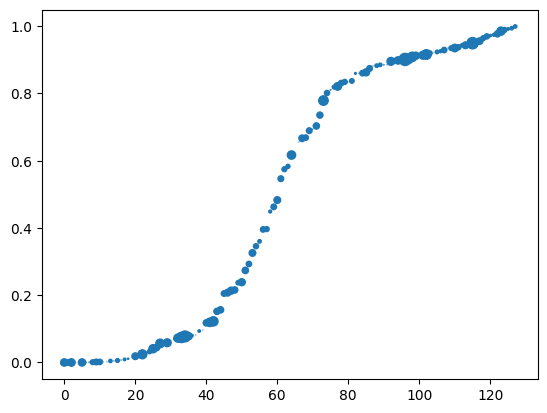

In [ ]:
# plot y prototypes
xs = kdm_gen_1.kdm.c_x.numpy()
ys = kdm_gen_1.kdm.c_y.numpy() / np.linalg.norm(kdm_gen_1.kdm.c_y.numpy(), axis=1, keepdims=True)
ys = ys ** 2
weights = np.abs(kdm_gen_1.kdm.c_w.numpy())
weights /= np.sum(weights)


sorted_ys = ys[:, 1]
idx = np.argsort(sorted_ys)


sorted_xs = xs[idx]
sorted_ys = sorted_ys[idx]
sorted_weights = weights[idx]


# create prototypes_df using sorted xs, ys and weights
prototypes_df = pd.DataFrame({'x': sorted_xs.tolist(),  'y':sorted_ys, 'w': sorted_weights})

plt.scatter(np.arange(len(prototypes_df['y'])),
            prototypes_df['y'], s=prototypes_df['w']*2000)

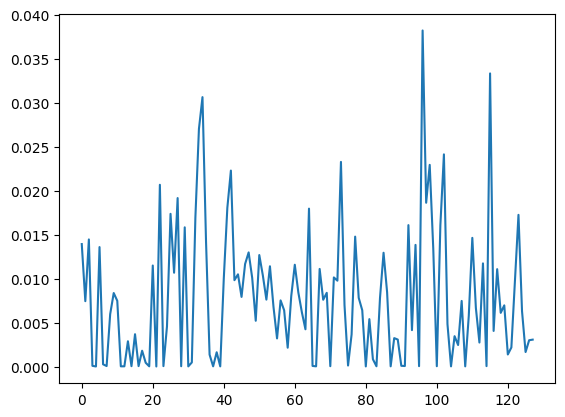

In [ ]:
plt.plot(sorted_weights)

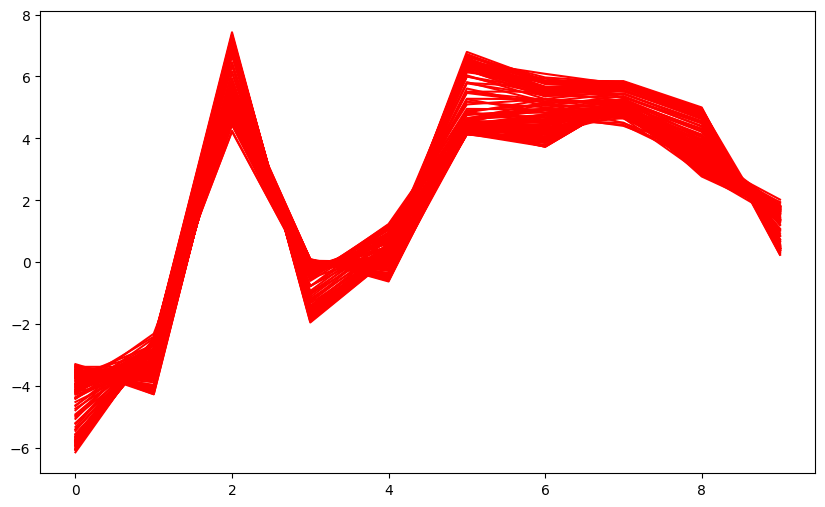

In [ ]:
import matplotlib.pyplot as plt

# Assuming prototypes_df and train_df_encoded are defined as in your code

plt.figure(figsize=(10, 6))  # Adjust figure size as needed

for index, row in prototypes_df.iterrows():
    prototype_encoding = row['x']


    # Plot the prototype's encoding vector
    plt.plot(np.arange(len(prototype_encoding)), prototype_encoding, color='red', label='Prototype Encoding')
plt.show()

In [ ]:
encoded_size = 10
encoder_1 = create_encoder(input_shape=(224, 224, 3), hidden_size=64, encoded_size=encoded_size)
encoder_1.set_weights(kdm_disc_1.encoder.get_weights())

train_ds_noshuf = create_tf_dataset(train_df, target_column='bound_circle_r',
                             batch_size=128, image_folder_path=images_path,
                                    shuffle=False)



In [ ]:
# prompt: Encode the images in train_ds_noshuf.
# Create a copy of train_df and add the encoding vector as a new column.

# Encode the images in train_ds_noshuf
encoded_images = encoder_1.predict(train_ds_noshuf)

# Create a copy of train_df
train_df_encoded = train_df.copy()

#reset indices
train_df_encoded.reset_index(drop=True, inplace=True)

# Add the encoding vector as a new column
train_df_encoded['encoding'] = encoded_images.tolist()

49/63 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

In [ ]:
# prompt: Use sklearn to find the k-nearest neighbors of each prototype in prototypes_df. in encoded images.
# Store the indices of the nn as a list in a column of a  prototypes_df.

from sklearn.neighbors import NearestNeighbors

# Assuming 'prototypes_df' and 'encoded_images' are defined as in your provided code

# Create a NearestNeighbors model with k=5 (you can adjust k as needed)
knn_model = NearestNeighbors(n_neighbors=20)

# Fit the model on the encoded images
knn_model.fit(encoded_images)

# Find the k-nearest neighbors for each prototype in prototypes_df
prototype_encodings = np.array([x for x in prototypes_df['x'].values])
distances, indices = knn_model.kneighbors(prototype_encodings)

# Store the indices of the nearest neighbors as a list in a new column 'nn_indices'
prototypes_df['nn_indices'] = indices.tolist()

In [ ]:
# prompt: For each prototype, calculate the average and std deviation of the bound_circle_r attribute of the nearest neighbors

# Assuming prototypes_df and train_df_encoded are defined as in your code

# Calculate average and std deviation of 'bound_circle_r' for nearest neighbors
prototypes_df['nn_bound_circle_r_avg'] = 0.0
prototypes_df['nn_bound_circle_r_std'] = 0.0

for index, row in prototypes_df.iterrows():
    nn_indices = row['nn_indices']
    nn_bound_circle_r = train_df_encoded.iloc[nn_indices]['bound_circle_r'].values
    prototypes_df.at[index, 'nn_bound_circle_r_avg'] = np.mean(nn_bound_circle_r)
    prototypes_df.at[index, 'nn_bound_circle_r_std'] = np.std(nn_bound_circle_r)

print(prototypes_df[['nn_bound_circle_r_avg', 'nn_bound_circle_r_std']])

In [ ]:
# prompt: Make a scatter plot of the y column vs nn_bound_circle_r_avg column using nn_bound_circle_r_std as error bars

# Calculate the 50th percentile of the 'w' column
percentile = prototypes_df['w'].quantile(0.5)

# Create a copy of prototypes_df with prototypes above the 50th percentile
prototypes_df_top = prototypes_df[prototypes_df['w'] >= percentile].copy()


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.errorbar(prototypes_df_top['y'], prototypes_df_top['nn_bound_circle_r_avg'],
             yerr=prototypes_df_top['nn_bound_circle_r_std'], fmt='o', capsize=5)
plt.xlabel('y')
plt.ylabel('nn_bound_circle_r_avg')
plt.title('Scatter Plot of y vs nn_bound_circle_r_avg with Error Bars')
plt.grid(True)
plt.show()

In [ ]:
# prompt: for a particular prototype given by prot_idx (prototype index):
# - print its weight and y value
# - show the nn images using the image path in train_df_encoded

import matplotlib.pyplot as plt

# Assuming prototypes_df and train_df_encoded are defined as in your code

prot_idx = 53  # Replace with the desired prototype index

# Print the weight and y value for the specified prototype
print(f"Prototype {prot_idx}:")
print(f"- Weight: {prototypes_df['w'][prot_idx]}")
print(f"- y value: {prototypes_df['y'][prot_idx]}")
print(f"- nn_bound_circle_r_avg: {prototypes_df['nn_bound_circle_r_avg'][prot_idx]}")
print(f"- nn_bound_circle_r_std: {prototypes_df['nn_bound_circle_r_std'][prot_idx]}")

# Show the NN images
nn_indices = prototypes_df['nn_indices'][prot_idx]

plt.figure(figsize=(15, 5))  # Adjust figure size as needed

for i, img_idx in enumerate(nn_indices):
  img_path = images_path + "/" + train_df_encoded['filename'][img_idx]
  img = plt.imread(img_path)
  plt.subplot(1, len(nn_indices), i + 1)
  plt.imshow(img)
  plt.title(f"NN {i+1}")
  plt.axis('off')
plt.show()

In [ ]:
def plot_prototype_info(prototypes_df, train_df_encoded, images_path, prot_idx):
    """
    Prints information about a prototype and displays its nearest neighbor images.

    Args:
        prototypes_df (pd.DataFrame): DataFrame containing prototype information.
        train_df_encoded (pd.DataFrame): DataFrame containing encoded training data.
        images_path (str): Path to the folder containing the images.
        prot_idx (int): Index of the prototype to visualize.
    """
    # Print the weight and y value for the specified prototype
    print(f"Prototype {prot_idx}:")
    print(f"- Weight: {prototypes_df['w'][prot_idx]}")
    print(f"- y value: {prototypes_df['y'][prot_idx]}")
    print(f"- nn_bound_circle_r_avg: {prototypes_df['nn_bound_circle_r_avg'][prot_idx]}")
    print(f"- nn_bound_circle_r_std: {prototypes_df['nn_bound_circle_r_std'][prot_idx]}")

    # Show the NN images
    nn_indices = prototypes_df['nn_indices'][prot_idx]

    plt.figure(figsize=(15, 5))  # Adjust figure size as needed

    for i, img_idx in enumerate(nn_indices):
        img_path = images_path + "/" + train_df_encoded['filename'][img_idx]
        img = plt.imread(img_path)
        plt.subplot(1, len(nn_indices), i + 1)
        plt.imshow(img)
        plt.title(f"NN {i+1}")
        plt.axis('off')
    plt.show()


idxs = prototypes_df_top.index.values
for i in range(0, len(idxs), 5):
    plot_prototype_info(prototypes_df_top, train_df_encoded, images_path, idxs[i])

In [ ]:
# prompt: Create a function that given a DF with prototypes create a 2-D visualization using t-sne

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE, MDS, Isomap, LocallyLinearEmbedding

def visualize_prototypes(prototypes_df, embed_class):
    """
    Creates a 2-D visualization of prototypes using t-SNE.

    Args:
        prototypes_df (pd.DataFrame): DataFrame containing prototype data,
            with a column 'x' representing the prototype encodings.
    """

    # Extract prototype encodings
    encodings = np.array(prototypes_df['x'].to_list())

    # Apply t-SNE
    # tsne = TSNE(n_components=2, random_state=42)  # You can adjust parameters here
    # embeddings = tsne.fit_transform(encodings)

    # apply MDS
    # mds = MDS(n_components=2, random_state=42)
    # embeddings = mds.fit_transform(encodings)

    # Apply Isomap
    embed_obj = embed_class(n_components=2)
    embeddings = embed_obj.fit_transform(encodings)

    # Apply LLE
    # lle = LocallyLinearEmbedding(n_components=2, random_state=41)
    # embeddings = lle.fit_transform(encodings)

    # Create the plot
    plt.figure(figsize=(10, 8))
    plt.scatter(embeddings[:, 0], embeddings[:, 1], c=prototypes_df['y'], cmap='viridis')
    plt.colorbar(label='y')
    plt.title(f'{embed_class.__name__} Visualization of Prototypes')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.show()

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def visualize_prototypes_img(prototypes_df, train_df_encoded, images_path, embed_class):
    """
    Creates a 2-D visualization of prototypes using Isomap and displays closest images.

    Args:
        prototypes_df (pd.DataFrame): DataFrame containing prototype data.
        train_df_encoded (pd.DataFrame): DataFrame with encoded training data and filenames.
        images_path (str): Path to image directory.
    """

    encodings = np.array(prototypes_df['x'].to_list())

    embed_obj = embed_class(n_components=2)
    embeddings = embed_obj.fit_transform(encodings)

    # Apply LLE
    # lle = LocallyLinearEmbedding(n_components=2, random_state=41)
    # embeddings = lle.fit_transform(encodings)


    indexes = prototypes_df.index.values

    fig, ax = plt.subplots(figsize=(10, 8))  # Create a single figure and axes
    ax.scatter(embeddings[:, 0], embeddings[:, 1], c=prototypes_df['y'], cmap='viridis', s=0)

    for i, embedding in enumerate(embeddings):
        nn_indices = prototypes_df['nn_indices'][indexes[i]]
        closest_image_idx = nn_indices[0]
        img_path = os.path.join(images_path, train_df_encoded['filename'][closest_image_idx])
        try:
            img = plt.imread(img_path)
            # Create an OffsetImage for each image
            imagebox = OffsetImage(img, zoom=0.15, alpha=0.7)  # Adjust zoom as needed
            ab = AnnotationBbox(imagebox, embedding, frameon=False)
            ax.add_artist(ab)
        except FileNotFoundError:
            print(f"Image not found at: {img_path}")

    plt.title(f'{embed_class.__name__} Visualization of Prototypes with Nearest Images')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.show()  # Display the plot after adding all images

visualize_prototypes(prototypes_df_top, TSNE)
visualize_prototypes_img(prototypes_df_top, train_df_encoded, images_path, TSNE)


In [ ]:
visualize_prototypes(prototypes_df_top, Isomap)
visualize_prototypes_img(prototypes_df_top, train_df_encoded, images_path, Isomap)
